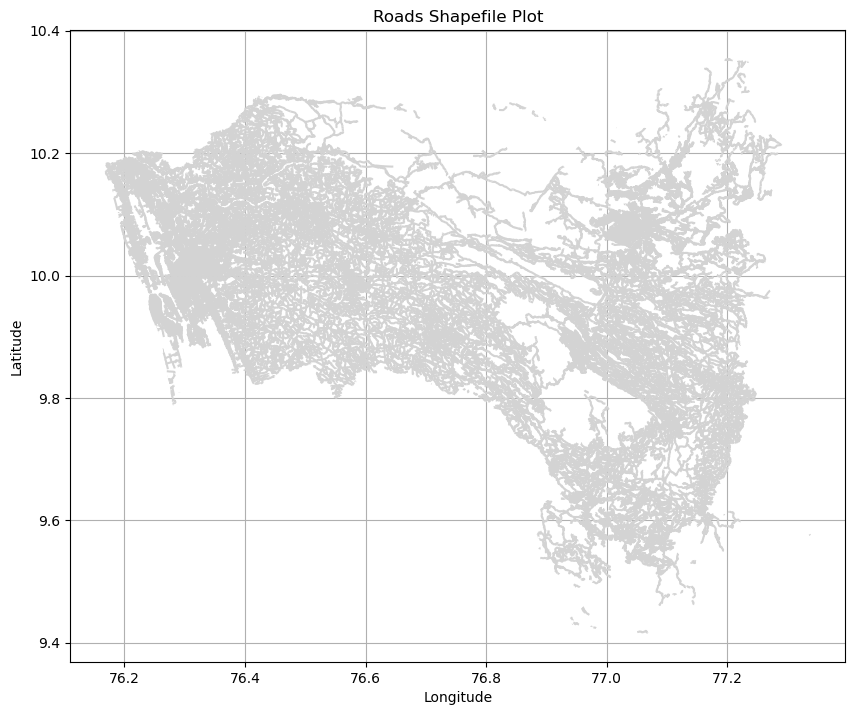

    Road_ID  Mean_Elevation  Mean_Slope
0   4747828      732.345455   89.999204
1  24837321        7.583333   89.980682
2  24837416        8.200000   89.977461
3  24952198        8.000000   89.984789
4  24952644        5.625000   89.993444


In [4]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import rasterio
import numpy as np
from rasterstats import zonal_stats

def plot_shapefile(shapefile_path):
    gdf = gpd.read_file(shapefile_path)
    fig, ax = plt.subplots(figsize=(10, 10))
    gdf.plot(ax=ax, edgecolor='black', color='lightgrey')
    ax.set_title("Roads Shapefile Plot")
    plt.xlabel("Longitude")
    plt.ylabel("Latitude")
    plt.grid(True)
    plt.show()

def compute_slope_rasterio(dem_path):
    # Open the DEM with Rasterio
    with rasterio.open(dem_path) as ds:
        elevation = ds.read(1)
        transform = ds.transform

    # Compute the gradient in the x and y directions
    dy, dx = np.gradient(elevation, transform.a, transform.e)
    
    # Compute the slope in degrees
    slope_rad = np.arctan(np.sqrt(dx**2 + dy**2))
    slope_deg = np.degrees(slope_rad)
    
    return slope_deg

def compute_zonal_statistics(shapefile_path, raster_data, transform):
    # Compute zonal statistics for each road
    stats = zonal_stats(shapefile_path, raster_data, affine=transform, stats="mean", nodata=-9999)
    return [s["mean"] for s in stats]

# Provide the paths to your shapefile and DEM
shapefile_path = "C:/Users/Rahul M/Documents/MSc GIS/Dissertation/study_area_roads/study_area_roads.shp"
dem_path = "C:/Users/Rahul M/Documents/MSc GIS/Dissertation/dem/output_SRTMGL1.tif"

# Plotting the shapefile
plot_shapefile(shapefile_path)

# Compute slope using rasterio and numpy
slope_data = compute_slope_rasterio(dem_path)

# Load the shapefile using geopandas
gdf = gpd.read_file(shapefile_path)

# Load the DEM using Rasterio for zonal stats
with rasterio.open(dem_path) as ds:
    dem_data = ds.read(1)
    transform = ds.transform

# Compute mean elevation and mean slope using zonal statistics
gdf["Mean_Elevation"] = compute_zonal_statistics(shapefile_path, dem_data, transform)
gdf["Mean_Slope"] = compute_zonal_statistics(shapefile_path, slope_data, transform)

# Creating a DataFrame to show results
results_df = pd.DataFrame({
    "Road_ID": gdf["osm_id"],  # Replace 'osm_id' if the ID column name is different
    "Mean_Elevation": gdf["Mean_Elevation"],
    "Mean_Slope": gdf["Mean_Slope"]
})

# Display the top rows of the dataframe
print(results_df.head())


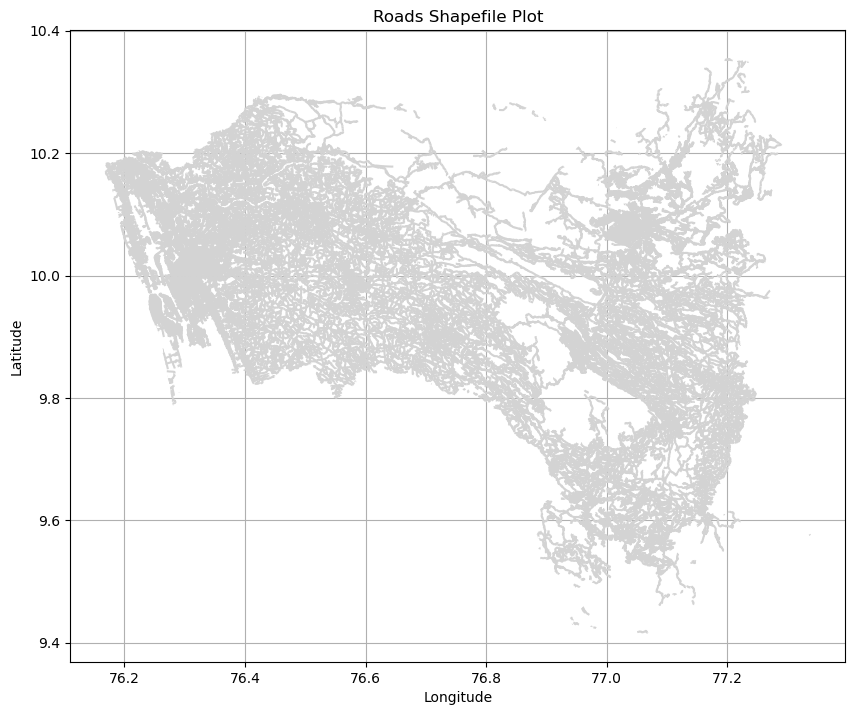

    Road_ID  Mean_Elevation  Mean_Slope  Mean_Precipitation
0   4747828      732.345455   89.999204                 NaN
1  24837321        7.583333   89.980682                 NaN
2  24837416        8.200000   89.977461                 NaN
3  24952198        8.000000   89.984789                 NaN
4  24952644        5.625000   89.993444                 NaN


In [5]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import rasterio
import numpy as np
from rasterstats import zonal_stats

def plot_shapefile(shapefile_path):
    gdf = gpd.read_file(shapefile_path)
    fig, ax = plt.subplots(figsize=(10, 10))
    gdf.plot(ax=ax, edgecolor='black', color='lightgrey')
    ax.set_title("Roads Shapefile Plot")
    plt.xlabel("Longitude")
    plt.ylabel("Latitude")
    plt.grid(True)
    plt.show()

def compute_slope_rasterio(dem_path):
    # Open the DEM with Rasterio
    with rasterio.open(dem_path) as ds:
        elevation = ds.read(1)
        transform = ds.transform

    # Compute the gradient in the x and y directions
    dy, dx = np.gradient(elevation, transform.a, transform.e)
    
    # Compute the slope in degrees
    slope_rad = np.arctan(np.sqrt(dx**2 + dy**2))
    slope_deg = np.degrees(slope_rad)
    
    return slope_deg

def compute_zonal_statistics(shapefile_path, raster_data, transform):
    # Compute zonal statistics for each road
    stats = zonal_stats(shapefile_path, raster_data, affine=transform, stats="mean", nodata=-9999)
    return [s["mean"] for s in stats]

# Provide the paths to your shapefile, DEM and Precipitation raster
shapefile_path = "C:/Users/Rahul M/Documents/MSc GIS/Dissertation/study_area_roads/study_area_roads.shp"
dem_path = "C:/Users/Rahul M/Documents/MSc GIS/Dissertation/dem/output_SRTMGL1.tif"
precipitation_path = "C:/Users/Rahul M/Documents/MSc GIS/Dissertation/chirps-v2.0.2018.08.09.tif/chirps-v2.0.2018.08.09.tif" 

# Plotting the shapefile
plot_shapefile(shapefile_path)

# Compute slope using rasterio and numpy
slope_data = compute_slope_rasterio(dem_path)

# Load the shapefile using geopandas
gdf = gpd.read_file(shapefile_path)

# Load the DEM using Rasterio for zonal stats
with rasterio.open(dem_path) as ds:
    dem_data = ds.read(1)
    transform = ds.transform

# Load the Precipitation raster using Rasterio for zonal stats
with rasterio.open(precipitation_path) as ds:
    precipitation_data = ds.read(1)

# Compute mean elevation, mean slope, and mean precipitation using zonal statistics
gdf["Mean_Elevation"] = compute_zonal_statistics(shapefile_path, dem_data, transform)
gdf["Mean_Slope"] = compute_zonal_statistics(shapefile_path, slope_data, transform)
gdf["Mean_Precipitation"] = compute_zonal_statistics(shapefile_path, precipitation_data, transform)

# Creating a DataFrame to show results
results_df = pd.DataFrame({
    "Road_ID": gdf["osm_id"],  # Replace 'osm_id' if the ID column name is different
    "Mean_Elevation": gdf["Mean_Elevation"],
    "Mean_Slope": gdf["Mean_Slope"],
    "Mean_Precipitation": gdf["Mean_Precipitation"]
})

# Display the top rows of the dataframe
print(results_df.head())


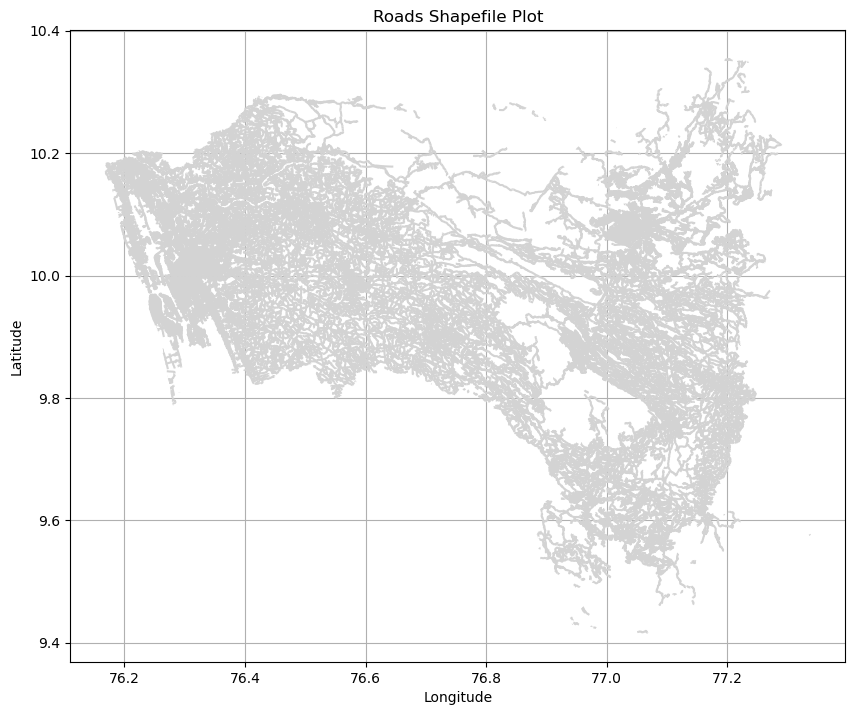

    Road_ID  Mean_Elevation  Mean_Slope  Mean_Precipitation  Flooded
0   4747828      732.345455   89.999204                 NaN        0
1  24837321        7.583333   89.980682                 NaN        0
2  24837416        8.200000   89.977461                 NaN        0
3  24952198        8.000000   89.984789                 NaN        0
4  24952644        5.625000   89.993444                 NaN        0


In [12]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import rasterio
import numpy as np
from rasterstats import zonal_stats

def plot_shapefile(shapefile_path):
    gdf = gpd.read_file(shapefile_path)
    fig, ax = plt.subplots(figsize=(10, 10))
    gdf.plot(ax=ax, edgecolor='black', color='lightgrey')
    ax.set_title("Roads Shapefile Plot")
    plt.xlabel("Longitude")
    plt.ylabel("Latitude")
    plt.grid(True)
    plt.show()

def compute_slope_rasterio(dem_path):
    # Open the DEM with Rasterio
    with rasterio.open(dem_path) as ds:
        elevation = ds.read(1)
        transform = ds.transform
    # Compute the gradient in the x and y directions
    dy, dx = np.gradient(elevation, transform.a, transform.e)
    
    # Compute the magnitude of the slope (rise over run)
    magnitude = np.sqrt(dx**2 + dy**2)

    # Compute the slope in degrees
    slope_deg = np.degrees(np.arctan(magnitude))

    
    
    return slope_deg

def compute_zonal_statistics(shapefile_path, raster_data, transform):
    # Compute zonal statistics for each road
    stats = zonal_stats(shapefile_path, raster_data, affine=transform, stats="mean", nodata=-9999)
    return [s["mean"] for s in stats]

# Paths
shapefile_path = "C:/Users/Rahul M/Documents/MSc GIS/Dissertation/study_area_roads/study_area_roads.shp"
dem_path = "C:/Users/Rahul M/Documents/MSc GIS/Dissertation/dem/output_SRTMGL1.tif"
precipitation_path = "C:/Users/Rahul M/Documents/MSc GIS/Dissertation/chirps-v2.0.2018.08.09.tif/chirps-v2.0.2018.08.09.tif" 
flooded_path = "C:/Users/Rahul M/Documents/MSc GIS/Dissertation/flooded_regions/S1A_IW_GRDH_5.tif" 

# Plotting the shapefile
plot_shapefile(shapefile_path)

# Compute slope using rasterio and numpy
slope_data = compute_slope_rasterio(dem_path)

# Load the shapefile using geopandas
gdf = gpd.read_file(shapefile_path)

# Load DEM and rasters using Rasterio for zonal stats
with rasterio.open(dem_path) as ds:
    dem_data = ds.read(1)
    transform = ds.transform

with rasterio.open(precipitation_path) as ds:
    precipitation_data = ds.read(1)

with rasterio.open(flooded_path) as ds:
    flooded_data = ds.read(1)

# Compute zonal statistics
gdf["Mean_Elevation"] = compute_zonal_statistics(shapefile_path, dem_data, transform)
gdf["Mean_Slope"] = compute_zonal_statistics(shapefile_path, slope_data, transform)
gdf["Mean_Precipitation"] = compute_zonal_statistics(shapefile_path, precipitation_data, transform)

# Checking for flooded roads
flooded_stats = zonal_stats(shapefile_path, flooded_data, affine=transform, stats="max", nodata=-9999)
gdf["Flooded"] = [1 if s["max"] and s["max"] > 0 else 0 for s in flooded_stats]


# Creating a DataFrame to show results
results_df = pd.DataFrame({
    "Road_ID": gdf["osm_id"],  # Assuming 'osm_id' is the ID column
    "Mean_Elevation": gdf["Mean_Elevation"],
    "Mean_Slope": gdf["Mean_Slope"],
    "Mean_Precipitation": gdf["Mean_Precipitation"],
    "Flooded": gdf["Flooded"]
})

# Display
print(results_df.head())


In [8]:
results_df.tail()

,Road_ID,Mean_Elevation,Mean_Slope,Mean_Precipitation,Flooded
68399,1204355938,696.000000,89.996817,NaN,0
68400,1204357368,34.307692,89.993058,NaN,0
68401,1204453980,8.600000,89.977817,NaN,0
68402,1204453981,9.000000,89.977359,NaN,0
68403,1204453982,8.666667,89.982696,NaN,0


In [11]:
results_df['Mean_Slope'].value_counts()

89.985765    454
89.968169    352
89.977492    281
89.981628    216
89.989934    213
            ... 
89.992775      1
89.986020      1
89.982619      1
89.983425      1
89.977817      1
Name: Mean_Slope, Length: 51558, dtype: int64